# Downscaling WD

In [1]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import os
import shutil
import csv
import pandas as pd
import torch_dl4ds as dds
import torch as pt

In [2]:
!python --version
#Should be Python 3.11.13

Python 3.11.13


In [3]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [4]:
uwrf_train

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB ...
    PSFC       (time, y, x) float32 155MB ...
    U10        (time, y, x) float32 155MB ...
    V10        (time, y, x) float32 155MB ...
    SWDOWN     (time, y, x) float32 155MB ...
    PBLH       (time, y, x) float32 155MB ...
    HGT        (time, y, x) float32 155MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [5]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [6]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'


for ds in nam_list:

            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'

In [7]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

# Main training code



Here you can run multiple trainings trying different combinations of predictor variables and architectures.

Running model with backbone=resnet, filters=8, blocks=8, epochs=25
Match found! Skipping training for: ('WD', 'WS', 'resnet', '8', '8', '0.001', 'inter_area', 'spc', 32, '25', 'mae', 'True', 'True', 'cpu')
Running model with backbone=resnet, filters=8, blocks=8, epochs=50
Match found! Skipping training for: ('WD', 'WS', 'resnet', '8', '8', '0.001', 'inter_area', 'spc', 32, '50', 'mae', 'True', 'True', 'cpu')
Training complete!
Running model with backbone=resnet, filters=8, blocks=8, epochs=25


Epoch 1/25, Train Loss: 0.6532, Val Loss: 0.4109


Epoch 2/25, Train Loss: 0.2822, Val Loss: 0.2044


Epoch 3/25, Train Loss: 0.1939, Val Loss: 0.1575


Epoch 4/25, Train Loss: 0.1777, Val Loss: 0.1519


...

Epoch 21/25, Train Loss: 0.1260, Val Loss: 0.0992


Epoch 22/25, Train Loss: 0.1240, Val Loss: 0.1212


Epoch 23/25, Train Loss: 0.1216, Val Loss: 0.0958


Epoch 24/25, Train Loss: 0.1213, Val Loss: 0.0995


Epoch 25/25, Train Loss: 0.1236, Val Loss: 0.1085
Total runtime: 2h 28m 4s
Plot saved to: /home/gvaillant1/downscaling/pretrained-models/WD/WD-Other-Models/learning_curve.png


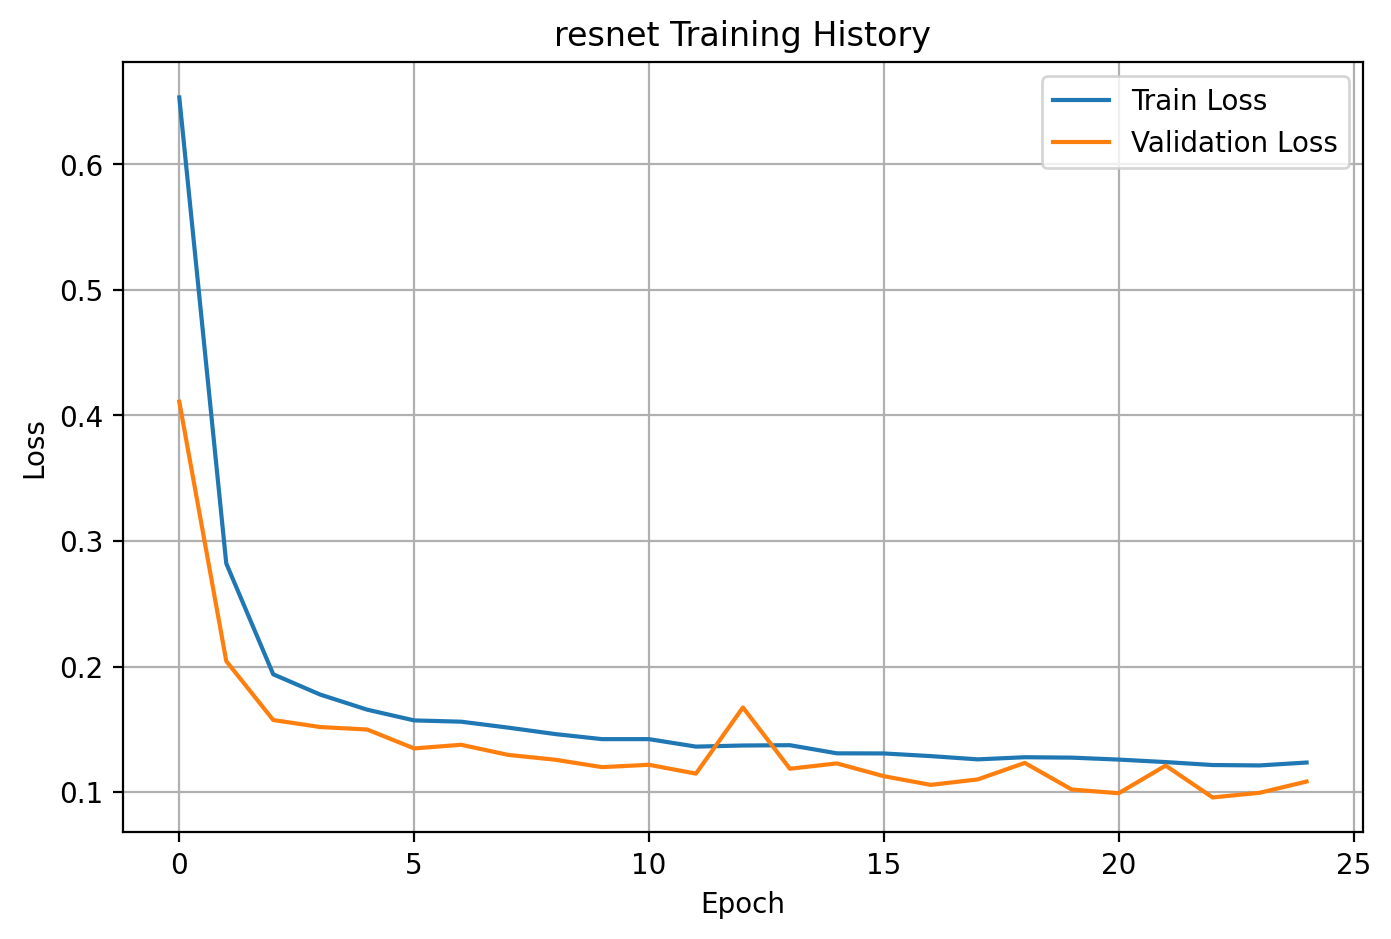

Running model with backbone=resnet, filters=8, blocks=8, epochs=50


Epoch 1/50, Train Loss: 0.7122, Val Loss: 0.5879


Epoch 2/50, Train Loss: 0.4279, Val Loss: 0.3592


Epoch 3/50, Train Loss: 0.2448, Val Loss: 0.1843


Epoch 4/50, Train Loss: 0.1978, Val Loss: 0.1682


...

Epoch 34/50, Train Loss: 0.1113, Val Loss: 0.0873


Epoch 35/50, Train Loss: 0.1101, Val Loss: 0.0876


Epoch 36/50, Train Loss: 0.1168, Val Loss: 0.1176


Epoch 37/50, Train Loss: 0.1121, Val Loss: 0.0849


Epoch 38/50, Train Loss: 0.1092, Val Loss: 0.0882
Early stopping triggered.
Total runtime: 3h 9m 31s
Plot saved to: /home/gvaillant1/downscaling/pretrained-models/WD/WD-Other-Models/learning_curve.png


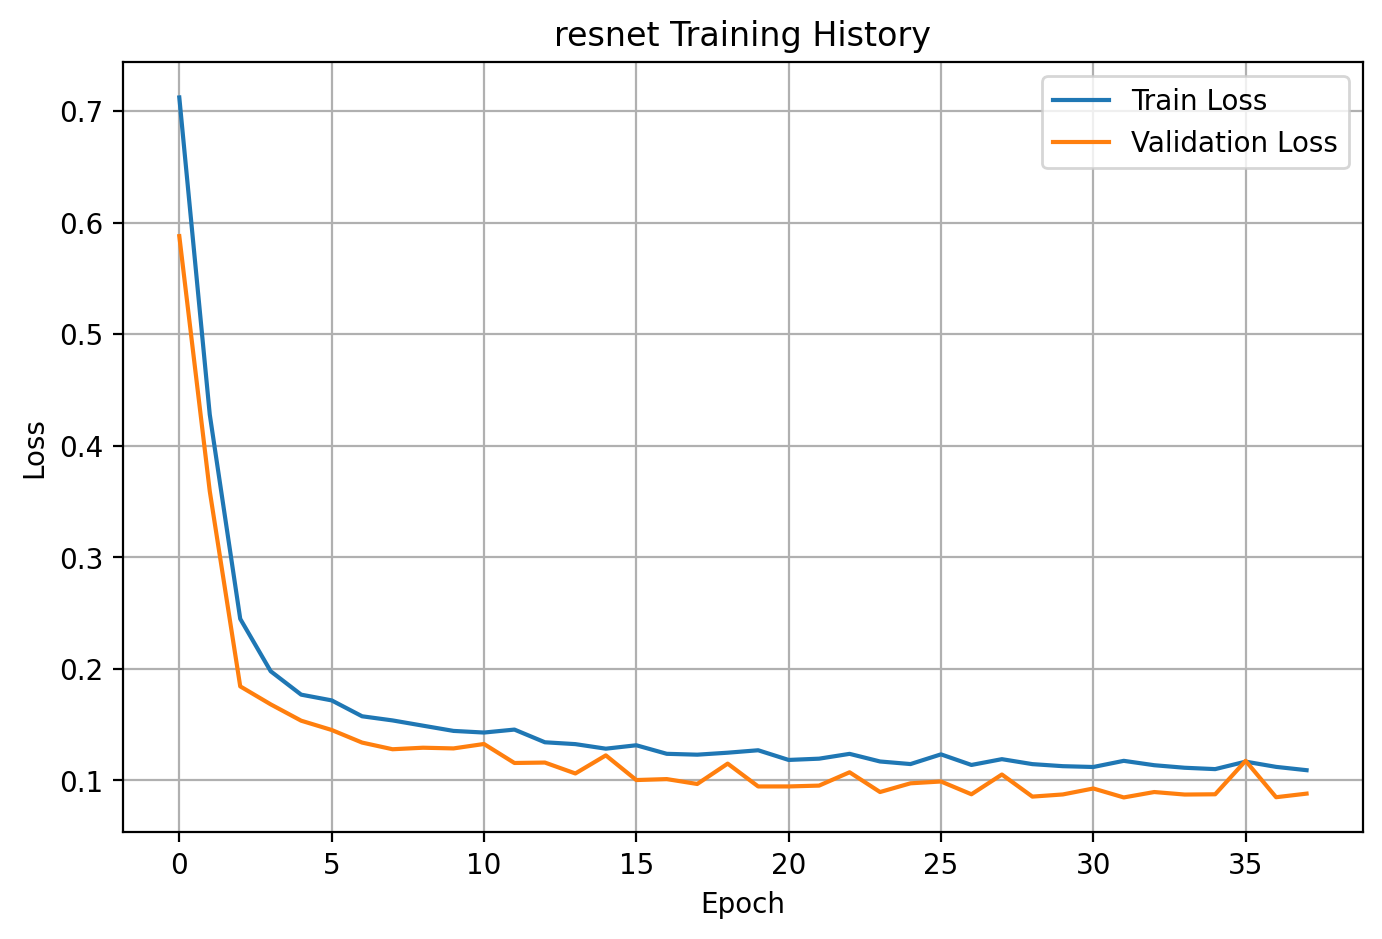

Copied to best model directory
Training complete!
Running model with backbone=resnet, filters=8, blocks=8, epochs=25


Epoch 1/25, Train Loss: 0.7515, Val Loss: 0.4526


Epoch 2/25, Train Loss: 0.3640, Val Loss: 0.2363


Epoch 3/25, Train Loss: 0.2204, Val Loss: 0.1812


Epoch 4/25, Train Loss: 0.1834, Val Loss: 0.1628


...

Epoch 21/25, Train Loss: 0.1159, Val Loss: 0.0906


Epoch 22/25, Train Loss: 0.1234, Val Loss: 0.1213


Epoch 23/25, Train Loss: 0.1181, Val Loss: 0.0883


Epoch 24/25, Train Loss: 0.1154, Val Loss: 0.0866


Epoch 25/25 [Training]:  42%|████████           | 36/85 [01:56<02:38,  3.24s/it]

In [ ]:
####################
## DOWNSCALING WD ##
####################

var_list = ['WD']
pred_var_list = ['WS', 'PSFC', 'T2']

for var in var_list:
    for pred_var in pred_var_list:
        # High resolution (uWRF) data
        var_hr_train = uwrf_train[var]
        var_hr_val = uwrf_val[var]
        var_hr_test = uwrf_test[var]

        pred_var_hr_train = uwrf_train[pred_var]
        pred_var_hr_val = uwrf_val[pred_var]
        pred_var_hr_test = uwrf_test[pred_var]

        # Low resolution (NAM) data
        var_lr_train = nam_train[var]
        var_lr_val = nam_val[var]
        var_lr_test = nam_test[var]

        pred_var_lr_train = nam_train[pred_var]
        pred_var_lr_val = nam_val[pred_var]
        pred_var_lr_test = nam_test[pred_var]

        # Normalize
        var_scaler_train = dds.TorchStandardScaler(axis=None)
        var_scaler_train.fit(var_hr_train)

        pred_var_scaler_train = dds.TorchStandardScaler(axis=None)
        pred_var_scaler_train.fit(pred_var_hr_train)

        # High resolution (targets)
        y_train = var_scaler_train.transform(var_hr_train)
        y_val = var_scaler_train.transform(var_hr_val)
        y_test = var_scaler_train.transform(var_hr_test)

        y_z_train = pred_var_scaler_train.transform(pred_var_hr_train)
        y_z_val = pred_var_scaler_train.transform(pred_var_hr_val)
        y_z_test = pred_var_scaler_train.transform(pred_var_hr_test)

        # Low resolution (inputs)
        x_train = var_scaler_train.transform(var_lr_train)
        x_val = var_scaler_train.transform(var_lr_val)
        x_test = var_scaler_train.transform(var_lr_test)

        x_z_train = pred_var_scaler_train.transform(pred_var_lr_train)
        x_z_val = pred_var_scaler_train.transform(pred_var_lr_val)
        x_z_test = pred_var_scaler_train.transform(pred_var_lr_test)


        y_train = np.expand_dims(y_train, axis=1)
        y_val = np.expand_dims(y_val, axis=1)
        y_test = np.expand_dims(y_test, axis=1)

        y_z_train = np.expand_dims(y_z_train, axis=1)
        y_z_val = np.expand_dims(y_z_val, axis=1)
        y_z_test = np.expand_dims(y_z_test, axis=1)

        x_train = np.expand_dims(x_train, axis=1)
        x_val = np.expand_dims(x_val, axis=1)
        x_test = np.expand_dims(x_test, axis=1)

        x_z_train = np.expand_dims(x_z_train, axis=1)
        x_z_val = np.expand_dims(x_z_val, axis=1)
        x_z_test = np.expand_dims(x_z_test, axis=1)
        
        pred_var_train = [y_z_train]
        pred_var_val = [y_z_val]
        pred_var_test = [y_z_test]

        # Paths and file setup
        best_model_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Best-Model"
        other_models_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Other-Models"
        csv_file = f"/home/gvaillant1/downscaling/results/{var}_torch_model_results.csv"
        results = pd.read_csv(csv_file) if os.path.exists(csv_file) else pd.DataFrame()

        # Model uniqueness tracking
        existing_model_ids = set()
        if not results.empty:
            for _, row in results.iterrows():
                model_id_row = (
                    row["Downscaled Variable"],
                    row["Predictor"],
                    row["Backbone"],
                    str(row["Filters"]),
                    str(row["Blocks"]),
                    str(row["Learning Rate"]),
                    row["Interpolation Method"],
                    row["Upsampling Method"],
                    row["Batch Size"],
                    str(row["Epochs"]),
                    row["Loss Function"],
                    str(row["Early Stopping"]),
                    str(row["Conv Block"]),
                    str(row["Device"])
                )
                existing_model_ids.add(model_id_row)

        # Loss tracking for early stopping
        min_losses = {}
        if not results.empty:
            for loss_fn in results['Loss Function'].unique():
                vals = results[results['Loss Function'] == loss_fn]['Test Loss'].astype(float)
                if not vals.empty:
                    min_losses[loss_fn] = vals.min()

        for backbone in ['resnet']:
            for filters in [8]:
                for blocks in [8]:
                    for epoch in [25, 50]:
                        ARCH_PARAMS = dict(
                            n_filters=filters,
                            n_blocks=blocks,
                            normalization=None,
                            dropout_rate=0.5,
                            dropout_variant='spatial',
                            attention=False,
                            activation='relu',
                            localcon_layer=True
                        )

                        print(f"Running model with backbone={backbone}, filters={filters}, blocks={blocks}, epochs={epoch}")

                        trainer = dds.TorchSupervisedTrainer(
                            backbone=backbone,
                            upsampling='spc',
                            data_train=y_train,
                            data_val=y_val,
                            data_test=y_test,
                            scale=3,
                            predictors_train=pred_var_train,
                            predictors_val=pred_var_val,
                            predictors_test=pred_var_test,
                            interpolation='inter_area',
                            batch_size=32,
                            loss='mae',
                            epochs=epoch,
                            steps_per_epoch=None,
                            validation_steps=None,
                            test_steps=None,
                            learning_rate=1e-3,
                            lr_decay_after=1e4,
                            early_stopping=True,
                            patience=6,
                            min_delta=0,
                            save=False,
                            save_bestmodel=False,
                            save_path=other_models_path,
                            show_plot=True,
                            verbose=True,
                            device='CPU',
                            **ARCH_PARAMS)

                        model_id = (
                            var,
                            "NULL" if trainer.predictors_train is None else pred_var,
                            backbone,
                            str(filters),
                            str(blocks),
                            str(trainer.learning_rate),
                            trainer.interpolation,
                            trainer.upsampling,
                            trainer.batch_size,
                            str(trainer.epochs),
                            trainer.loss,
                            str(trainer.early_stopping),
                            str(ARCH_PARAMS["localcon_layer"]),
                            str(trainer.device)
                        )

                        if model_id in existing_model_ids:
                            print("Match found! Skipping training for:", model_id)
                            continue

                        trainer.run()

                        val_loss = trainer.val_loss if hasattr(trainer, "val_loss") else float("inf")
                        training_runtime = trainer.training_runtime if hasattr(trainer, "training_runtime") else "NULL"

                        # Always save to "Other Models" first
                        os.makedirs(other_models_path, exist_ok=True)
                        model_filename = f"{var.lower()}_model.pth"
                        model_file_path = os.path.join(other_models_path, model_filename)
                        pt.save(trainer.model.state_dict(), model_file_path)

                        # If this is the best model so far (per loss function), copy to "Best Model"
                        if trainer.loss not in min_losses or val_loss < min_losses[trainer.loss]:
                            min_losses[trainer.loss] = val_loss
                            os.makedirs(best_model_path, exist_ok=True)
                            shutil.copy(model_file_path, os.path.join(best_model_path, model_filename))
                            model_save_path = best_model_path
                            print("Copied to best model directory")
                        else:
                            model_save_path = other_models_path

                        # Log result
                        new_result = pd.DataFrame([[
                            var,
                            "NULL" if trainer.predictors_train is None else pred_var,
                            round(val_loss, 4),
                            backbone,
                            filters,
                            blocks,
                            trainer.epochs,
                            sum(p.numel() for p in trainer.model.parameters() if p.requires_grad),
                            trainer.upsampling,
                            trainer.interpolation,
                            trainer.batch_size,
                            trainer.learning_rate,
                            trainer.loss,
                            trainer.early_stopping,
                            training_runtime,
                            model_save_path,
                            ARCH_PARAMS["localcon_layer"],
                            trainer.device
                        ]], columns=[
                            "Downscaled Variable", "Predictor", "Test Loss",
                            "Backbone", "Filters", "Blocks",
                            "Epochs", "Parameters", "Upsampling Method",
                            "Interpolation Method", "Batch Size", "Learning Rate",
                            "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"
                        ])

                        # Append the new result to CSV immediately
                        if os.path.exists(csv_file):
                            new_result.to_csv(csv_file, mode='a', index=False, header=False)
                        else:
                            new_result.to_csv(csv_file, mode='w', index=False, header=True)
                        
                        # Reload CSV so next model can compare against updated results
                        results = pd.read_csv(csv_file)

        print("Training complete!")
